# Actividad Individual Data Wrangling - PARTE A

**Angel Irwin Briseño Fierro A01796844**

En esta practica se realizara el EDA y proceso de limpieza de los datasets provistos "room-occupancy-estimation", original y modificado, con la finalidad de obtener una comparacion tal que evidencie la influencia de estos procesos en los datos y que pueden repercutir en procesos mas adelante en el desarrollo de modelos de ML.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns
import json
from pathlib import Path

## Cargar Dataset original

In [2]:
ogDf = pd.read_csv(r'D:\Master\MLops\A03_Data_Cleaning_EDA\room-occupancy-estimation\original.csv', keep_default_na=False)
# ogDf = pd.read_csv('./original.csv', keep_default_na=False)
ogDf.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [3]:
ogDf.describe().T

,count,mean,std,min,25%,50%,75%,max
S1_Temp,10129.0,25.454012,0.351351,24.940000,25.190000,25.38,25.63,26.380000
S2_Temp,10129.0,25.546059,0.586325,24.750000,25.190000,25.38,25.63,29.000000
S3_Temp,10129.0,25.056621,0.427283,24.440000,24.690000,24.94,25.38,26.190000
S4_Temp,10129.0,25.754125,0.356434,24.940000,25.440000,25.75,26.00,26.560000
S1_Light,10129.0,25.445059,51.011264,0.000000,0.000000,0.00,12.00,165.000000
S2_Light,10129.0,26.016290,67.304170,0.000000,0.000000,0.00,14.00,258.000000
S3_Light,10129.0,34.248494,58.400744,0.000000,0.000000,0.00,50.00,280.000000
S4_Light,10129.0,13.220259,19.602219,0.000000,0.000000,0.00,22.00,74.000000
S1_Sound,10129.0,0.168178,0.316709,0.060000,0.070000,0.08,0.08,3.880000
S2_Sound,10129.0,0.120066,0.266503,0.040000,0.050000,0.05,0.06,3.440000


In [4]:
print(f"Rows: {ogDf.shape[0]:,}")
print(f"Columns: {ogDf.shape[1]}")

# Compact data-quality summary
data_quality = pd.DataFrame({
    "dtype": ogDf.dtypes,
    "missing": ogDf.isna().sum(),
    "missing_pct": ogDf.isna().mean() * 100,
    "n_unique": ogDf.nunique()
})

data_quality.sort_values("missing_pct", ascending=False)

Rows: 10,129
Columns: 19


,dtype,missing,missing_pct,n_unique
Date,object,0,0.0,7
Time,object,0,0.0,10129
S1_Temp,float64,0,0.0,24
S2_Temp,float64,0,0.0,69
S3_Temp,float64,0,0.0,29
S4_Temp,float64,0,0.0,27
S1_Light,int64,0,0.0,68
S2_Light,int64,0,0.0,82
S3_Light,int64,0,0.0,177
S4_Light,int64,0,0.0,75


In [5]:
n_duplicates = ogDf.duplicated().sum()
duplicate_pct = 100 * n_duplicates / len(ogDf)

print(f"Duplicated rows: {n_duplicates:,}")
print(f"Percentage of duplicated rows: {duplicate_pct:.2f}%")

Duplicated rows: 0
Percentage of duplicated rows: 0.00%


In [6]:
exclude = ["Date", "Time"]

for col in ogDf.columns:
    if col not in exclude:
        ogDf[col] = pd.to_numeric(ogDf[col], errors="coerce")
        
numeric_features = [
    col for col in ogDf.select_dtypes(include=np.number).columns
    if col != "Room_Occupancy_Count"
]

univariate_summary = ogDf[numeric_features].describe().T

univariate_summary["median"] = ogDf[numeric_features].median()
univariate_summary["skewness"] = ogDf[numeric_features].skew()
univariate_summary["kurtosis"] = ogDf[numeric_features].kurt()

univariate_summary[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max",
     "skewness", "kurtosis"]
].sort_values("skewness", key=lambda x: x.abs(), ascending=False)

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
S4_Sound,10129.0,0.103840,0.08,0.120683,0.050000,0.060000,0.08,0.10,3.400000,10.952134,211.172069
S2_Sound,10129.0,0.120066,0.05,0.266503,0.040000,0.050000,0.05,0.06,3.440000,6.881610,62.472799
S3_Sound,10129.0,0.158119,0.06,0.413637,0.040000,0.060000,0.06,0.07,3.670000,5.994767,39.477822
S1_Sound,10129.0,0.168178,0.08,0.316709,0.060000,0.070000,0.08,0.08,3.880000,5.450448,39.415196
S7_PIR,10129.0,0.079574,0.00,0.270645,0.000000,0.000000,0.00,0.00,1.000000,3.107460,7.657822
S6_PIR,10129.0,0.090137,0.00,0.286392,0.000000,0.000000,0.00,0.00,1.000000,2.862811,6.196913
S2_Light,10129.0,26.016290,0.00,67.304170,0.000000,0.000000,0.00,14.00,258.000000,2.827817,6.187379
S2_Temp,10129.0,25.546059,25.38,0.586325,24.750000,25.190000,25.38,25.63,29.000000,2.355681,6.506295
S3_Light,10129.0,34.248494,0.00,58.400744,0.000000,0.000000,0.00,50.00,280.000000,2.100069,3.885540
S5_CO2,10129.0,460.860401,360.00,199.964940,345.000000,355.000000,360.00,465.00,1270.000000,1.975692,3.001375


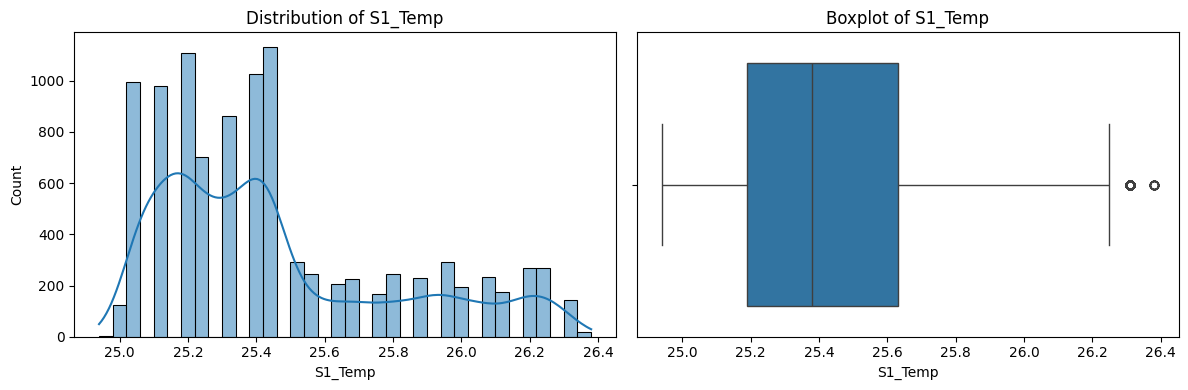

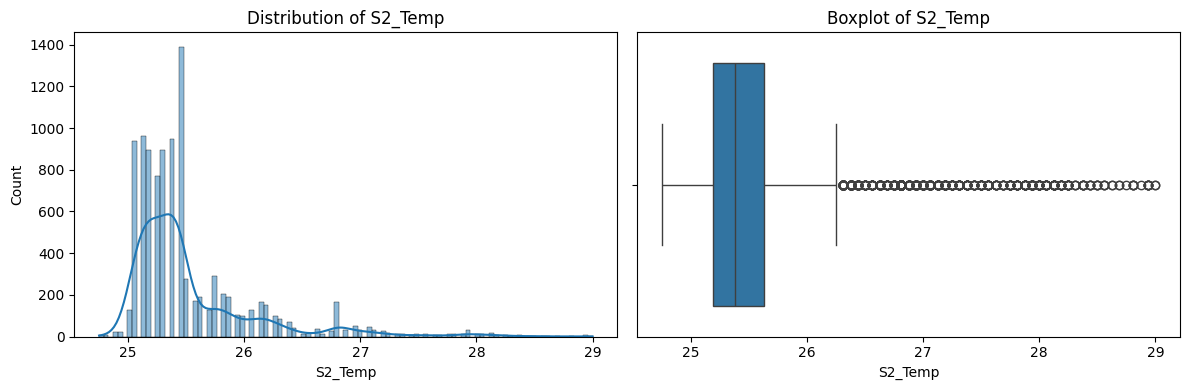

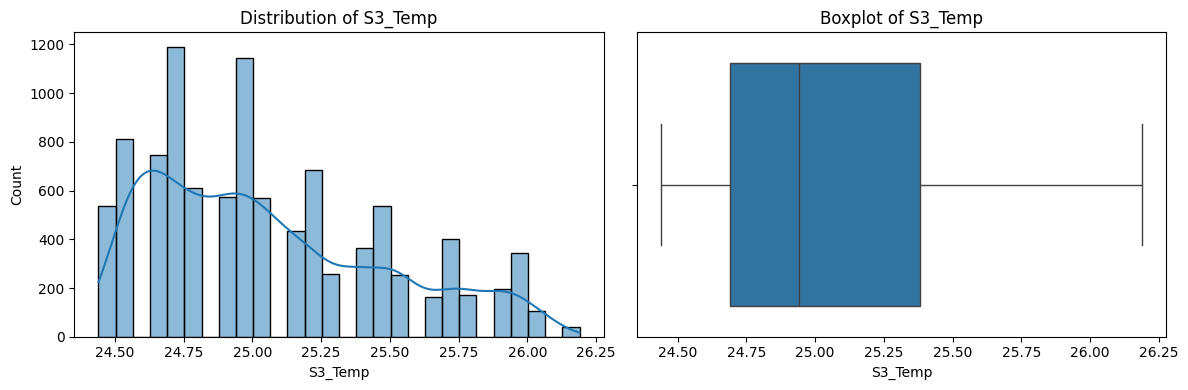

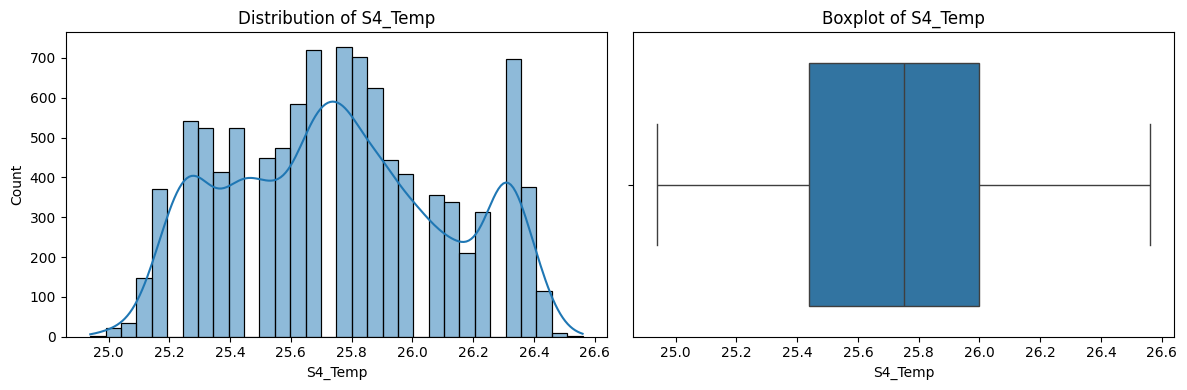

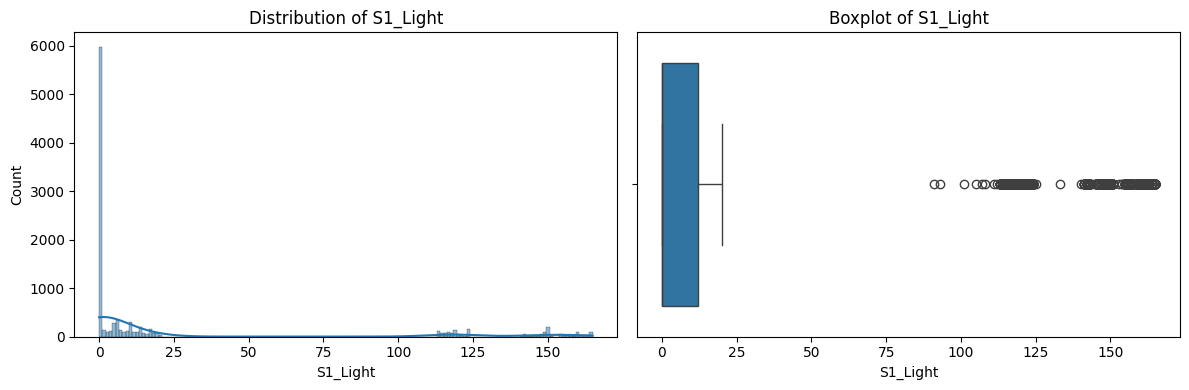

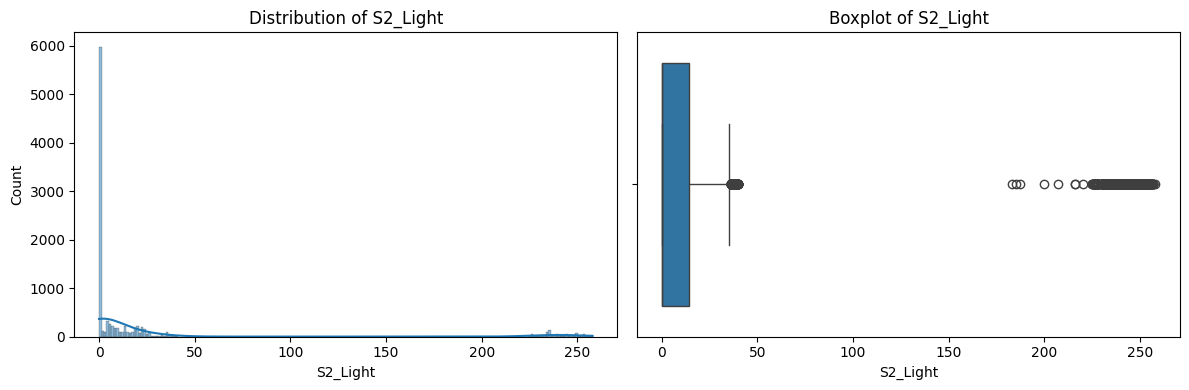

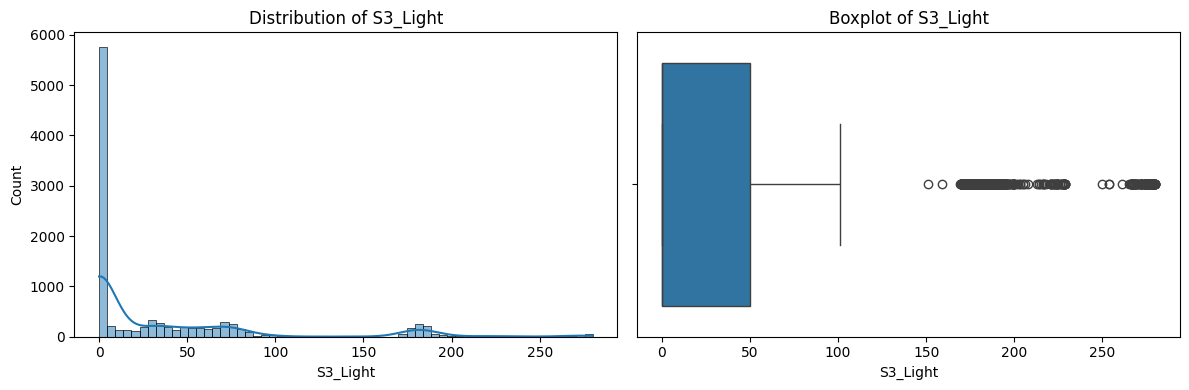

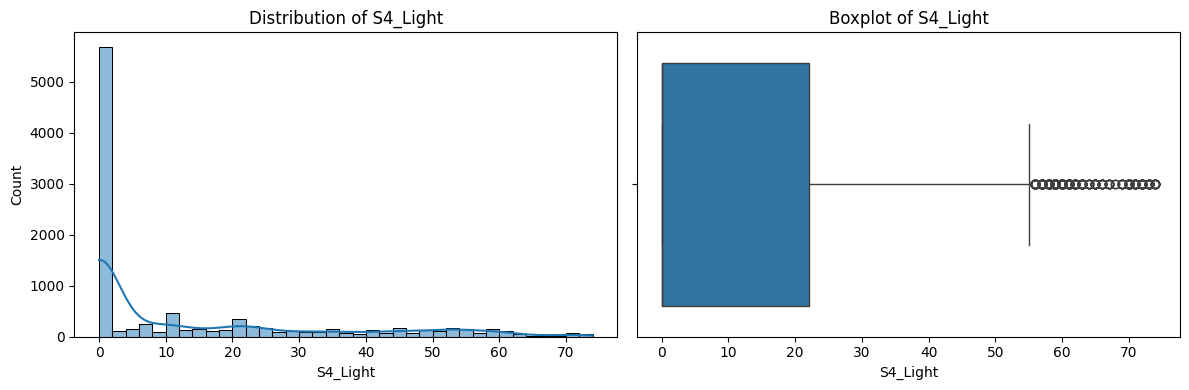

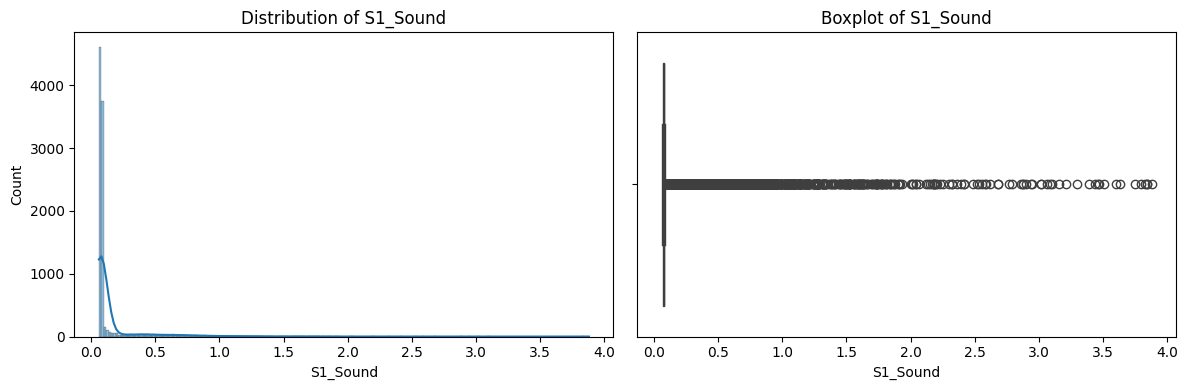

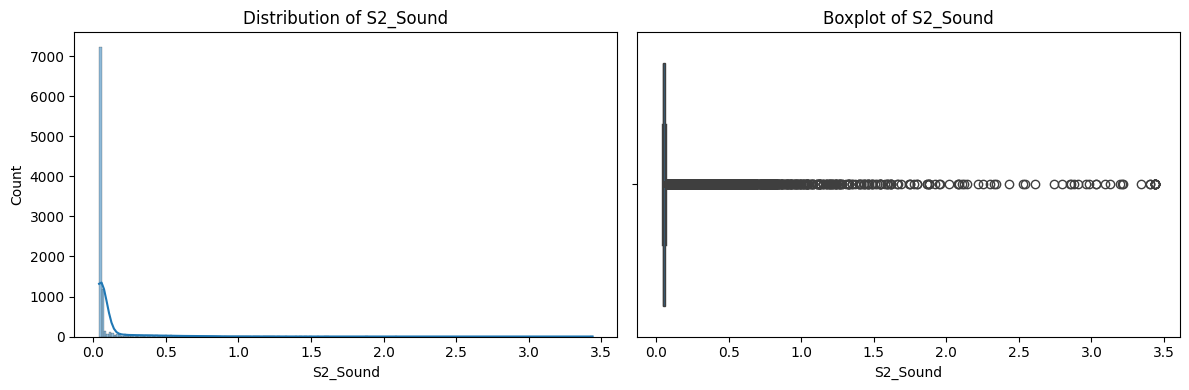

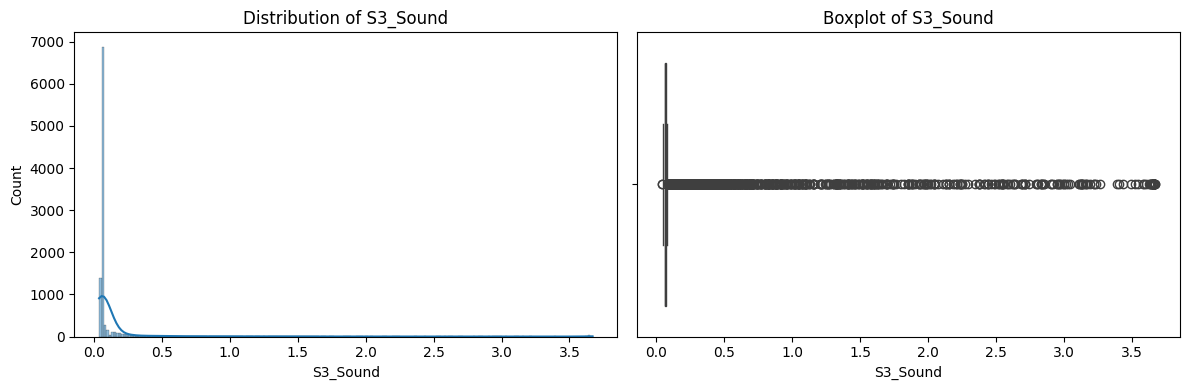

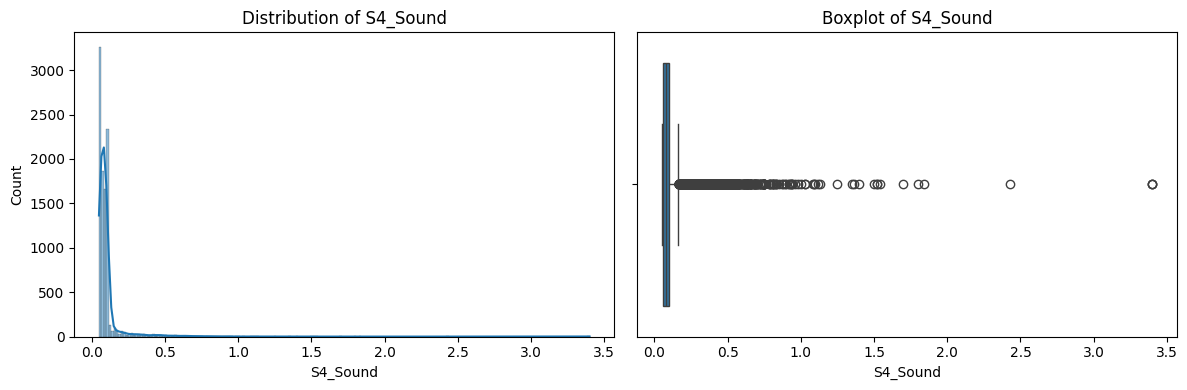

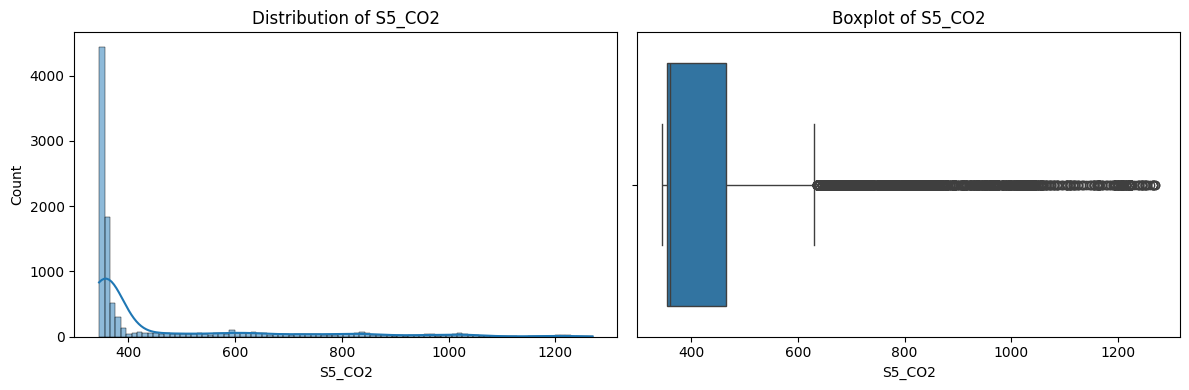

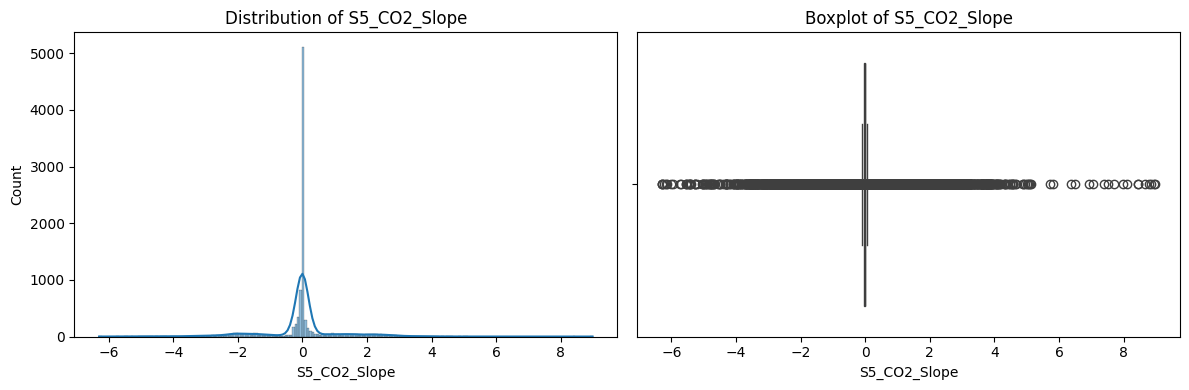

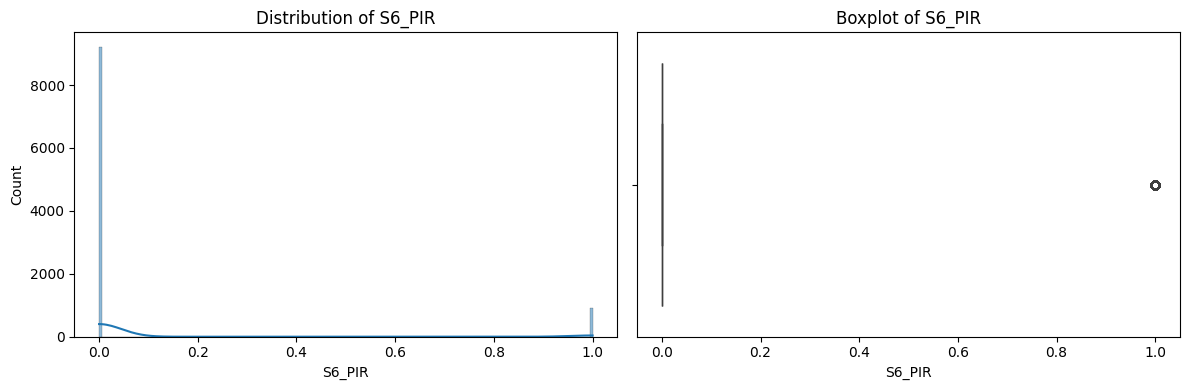

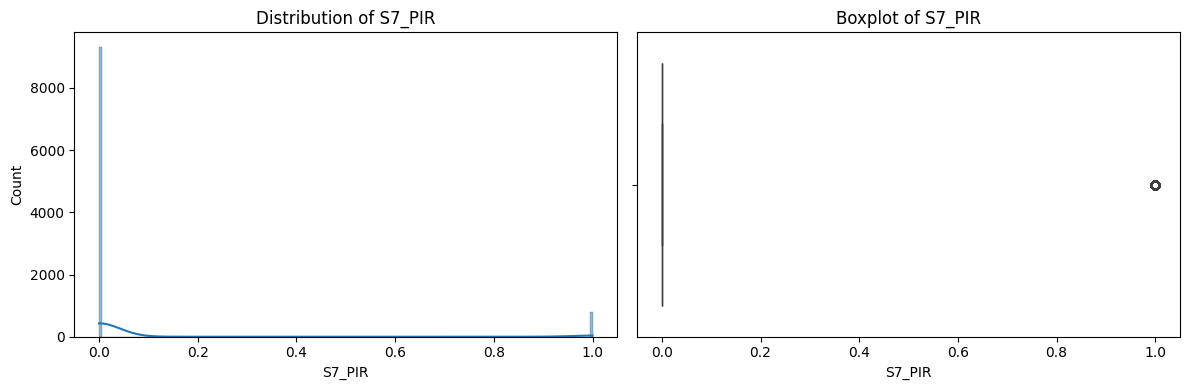

In [7]:
# Distribution + boxplot for every numerical predictor
for column in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(
        data=ogDf,
        x=column,
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribution of {column}")

    sns.boxplot(
        data=ogDf,
        x=column,
        ax=axes[1]
    )
    axes[1].set_title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

**Análisis de la variable objetivo**

Con base en los datos presentados, la variable room_ocupancy_count puede ser utilizada como variable objetivo.
Al verificar las clases, se puede observar un gran desbalance en las variables, la clase 0 (sin ser ocupados) ocupa mas del 80% mas de los registros. 

In [8]:
quality_summary = pd.DataFrame({
    "count": ogDf["Room_Occupancy_Count"].value_counts().sort_index(),
    "percentage": ogDf["Room_Occupancy_Count"].value_counts(normalize=True).sort_index() * 100
})

quality_summary

,count,percentage
Room_Occupancy_Count,,
0,8228,81.232106
1,459,4.531543
2,748,7.384737
3,694,6.851614


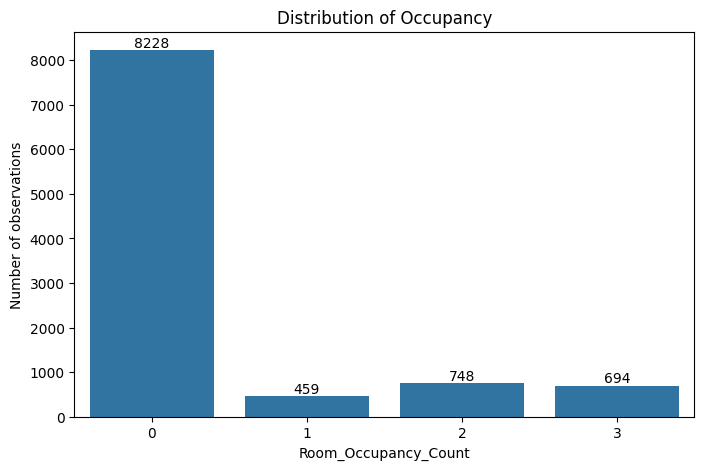

In [9]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=ogDf, x="Room_Occupancy_Count")

plt.title("Distribution of Occupancy")
plt.xlabel("Room_Occupancy_Count")
plt.ylabel("Number of observations")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Dataset modificado

In [10]:
metadata = json.loads(Path(r'D:\Master\MLops\A03_Data_Cleaning_EDA\room-occupancy-estimation\metadata.json').read_text())
# metadata = json.loads(Path('./metadata.json').read_text())
print(metadata['rates'])

{'dup_rate': 0.02, 'nan_rate': 0.01, 'outlier_rate': 0.01, 'bad_token_rate': 0.005, 'obj_noise_rate': 0.05, 'add_mixed_type': True}


In [77]:
modDf = pd.read_csv(r'D:\Master\MLops\A03_Data_Cleaning_EDA\room-occupancy-estimation\modified.csv')
# ogDf = pd.read_csv('./modified.csv')
initDF_Len = len(modDf)
modDf.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,mixed_type_col
0,2017/12/22,10:49:41,24.94,345.75,24.56,25.38,121.0,34.0,53.0,40.0,0.08,0.19,0.06,0.06,390.0,0.769230769231,0.0,0.0,1.0,599
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121.0,33.0,53.0,40.0,0.93,0.05,0.06,0.06,390.0,0.646153846154,0.0,0.0,1.0,NaN
2,2017/12/22,10:50:42,25.0,24.75,24.5,25.44,121.0,34.0,53.0,40.0,0.43,0.11,0.08,0.06,390.0,0.519230769231,0.0,0.0,1.0,unknown
3,2017/12/22,10:51:13,25.0,24.75,24.56,25.44,121.0,34.0,53.0,40.0,0.41,0.1,0.1,0.09,390.0,0.388461538462,0.0,0.0,1.0,584
4,2017/12/22,10:51:44,25.0,24.75,24.56,25.44,121.0,34.0,54.0,40.0,0.18,0.06,0.06,0.06,390.0,0.253846153846,0.0,0.0,1.0,bad


Se menciona en la metadata que la columna "Add_mixed_type" fue añadida, por lo que en la tabla original no existe, ademas se observa que, como su nombre lo dice, multiples valores de diferente tipo, por lo que puede ser removida del analisis

In [78]:
modDf.drop(axis=1, labels=['mixed_type_col'],inplace=True)
print(f"Rows: {modDf.shape[0]:,}")
print(f"Columns: {modDf.shape[1]}")


Rows: 10,331
Columns: 19


En este caso, Pandas detecto todo del tipo "object" lo que indica que todas las columnas podrian estar contaminados con caracteres o valores incorrectos.

In [79]:
def CheckDataQ(df : pd.DataFrame):
    data_quality = pd.DataFrame({
        "dtype": df.dtypes,
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "n_unique": df.nunique()
    })

    display(data_quality.sort_values("missing_pct", ascending=False))

CheckDataQ(modDf)

,dtype,missing,missing_pct,n_unique
Room_Occupancy_Count,object,132,1.277708,56
S3_Light,object,131,1.268028,338
S2_Temp,object,128,1.238989,228
S3_Temp,object,124,1.200271,169
S2_Light,object,122,1.180912,218
S5_CO2,object,121,1.171232,381
S4_Light,object,118,1.142193,227
S7_PIR,object,116,1.122834,54
S2_Sound,object,115,1.113155,322
S1_Temp,object,115,1.113155,160


## Pruebas diagnosticas

### Variables de fecha y tiempo

In [80]:
#Conversion de variables temporales
modDf['Date'] = modDf['Date'].str.strip().apply(pd.to_datetime)
modDf['Time'] = modDf['Time'].str.strip().apply(pd.to_timedelta)
modDf.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10331 entries, 0 to 10330
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   Date                  10238 non-null  datetime64[ns] 
 1   Time                  10225 non-null  timedelta64[ns]
 2   S1_Temp               10216 non-null  object         
 3   S2_Temp               10203 non-null  object         
 4   S3_Temp               10207 non-null  object         
 5   S4_Temp               10221 non-null  object         
 6   S1_Light              10217 non-null  object         
 7   S2_Light              10209 non-null  object         
 8   S3_Light              10200 non-null  object         
 9   S4_Light              10213 non-null  object         
 10  S1_Sound              10221 non-null  object         
 11  S2_Sound              10216 non-null  object         
 12  S3_Sound              10228 non-null  object         
 13  S

De esta manera podremos intentar 

### Variables numericas

In [43]:
numeric_cols = [
    "S1_Temp", "S2_Temp", "S3_Temp", "S4_Temp",
    "S1_Light", "S2_Light", "S3_Light", "S4_Light",
    "S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound",
    "S5_CO2", "S5_CO2_Slope",
    "Room_Occupancy_Count"
]

def numericErrors(df : pd.DataFrame, colList : list):
    """
    This function is intented to be use with columns in a dataframe that are not register as numeric type but it should be consider as such.
    
        Parameters:

        df : Dataframe to be analize.
    
        colList : List that contain the numeric columns to be analized.

        Returns:

        List :  0 - Error Dataframe(Contains the row number, the column name and the incompatible value), 1 - List with row number that are duplicate 

        
    """
    errors = []
    for col in colList:
        converted = pd.to_numeric(df[col], errors="coerce")
        invalid = converted.isna() #df[col].notna() & 

        for idx in df.index[invalid]:
            errors.append({
                "row": idx,
                "column": col,
                "value": df.loc[idx, col]
            })
    e_df = pd.DataFrame(errors)
    same_id_rows = e_df[e_df.duplicated(subset=["row"], keep=False)]

    return [e_df,list(set(same_id_rows['row'].to_list()))]

numError_DF, numError_sameRow = numericErrors(modDf,numeric_cols)

print(f'Columnas analizadas: {len(numeric_cols)}')
print(f'Filas con valores erroneos: {numError_DF.shape[0]}')
print(f'Filas con mas de un valor erroneo: {len(numError_sameRow)}')

numError_DF.nunique()


Columnas analizadas: 15
Filas con valores erroneos: 2314
Filas con mas de un valor erroneo: 214


row       2083
column      15
value        9
dtype: int64

In [44]:
numError_DF.head()

,row,column,value
0,12,S1_Temp,NaN
1,29,S1_Temp,?
2,33,S1_Temp,NaN
3,67,S1_Temp,NaN
4,152,S1_Temp,?


In [46]:
numError_DF['value'].isna().sum()

np.int64(1749)

Despues de aplicar la limpieza inicial, se obtuvieron 2081 filas con valores erroneos, de los cuales 1749 son del tipo NaN despues de la conversion a tipo numerico.

In [47]:
bad_rows = numError_DF["row"].unique()
modDF_delR = modDf.drop(index=bad_rows).copy()

modDF_delR[numeric_cols] = modDF_delR[numeric_cols].apply(
pd.to_numeric
)

modDF_delR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8248 entries, 0 to 10330
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   Date                  8175 non-null   datetime64[ns] 
 1   Time                  8159 non-null   timedelta64[ns]
 2   S1_Temp               8248 non-null   float64        
 3   S2_Temp               8248 non-null   float64        
 4   S3_Temp               8248 non-null   float64        
 5   S4_Temp               8248 non-null   float64        
 6   S1_Light              8248 non-null   float64        
 7   S2_Light              8248 non-null   float64        
 8   S3_Light              8248 non-null   float64        
 9   S4_Light              8248 non-null   float64        
 10  S1_Sound              8248 non-null   float64        
 11  S2_Sound              8248 non-null   float64        
 12  S3_Sound              8248 non-null   float64        
 13  S4_Soun

#### Validación de rangos de dominio

* Rango de temperatura "normal" = 10 - 40 C
* Rango "normal" de iluminación = 0 - 300 lux (300 lux es considerado apropiado para areas de conferencia pero aun apropiado)
* Rango normal de CO2 = 0 - 1000 ppm (de acuerdo con [2])
* Rango de personas por habitacion = 0 - 4 (No hay indicación real de cual es el limite por lo que se pondrá a prueba)
* Rango normal de sonido = 0 - 5 v (si el dataset es [3], el voltage tipico de sensores podria ser 3.3 o 5v)

Referencias:
1. Lumenloop. (s. f.). Hotel lighting calculator. lumenloop.co.uk
2. CO2 Meter. (2026, 3 de agosto). Carbon Dioxide Levels Chart. CO2Meter.com. https://www.co2meter.com/blogs/news/carbon-dioxide-indoor-levels-chart
3. Ananth, R. (2021). Room Occupancy Estimation Data Set [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/ananthr1/room-occupancy-estimation-data-set/data

In [21]:
rangeTemp = [10.0,40.0]
rangeLux = [0,300.0]
rangoCo2 = [0,1000]
rangoP = [0,4]
rangoSonido = [0,5]
modDf_NumC = modDF_delR.loc[((modDF_delR.S1_Temp.between(*rangeTemp)) & (modDF_delR.S2_Temp.between(*rangeTemp)) & (modDF_delR.S3_Temp.between(*rangeTemp)) & (modDF_delR.S4_Temp.between(*rangeTemp))) & 
                               ((modDF_delR.S1_Light.between(*rangeLux)) & (modDF_delR.S2_Light.between(*rangeLux)) & (modDF_delR.S3_Light.between(*rangeLux)) & (modDF_delR.S4_Light.between(*rangeLux))) &
                               (modDF_delR.S5_CO2.between(*rangoCo2)) &
                               ((modDF_delR.S1_Sound.between(*rangoSonido)) & (modDF_delR.S2_Sound.between(*rangoSonido)) & (modDF_delR.S3_Sound.between(*rangoSonido)) & (modDF_delR.S4_Sound.between(*rangoSonido))) &
                               (modDF_delR.Room_Occupancy_Count.between(*rangoP))]

modDf_NumC.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
Time,7096,0 days 11:39:50.215896279,0 days 07:16:38.765910327,0 days 00:00:37,0 days 05:07:24.500000,0 days 11:23:19,0 days 17:56:39.500000,0 days 23:59:36
S1_Temp,7166.0,25.418624,0.317553,24.94,25.19,25.38,25.56,26.31
S2_Temp,7166.0,25.493346,0.524918,24.75,25.19,25.38,25.56,29.0
S3_Temp,7166.0,25.014777,0.393447,24.44,24.69,24.94,25.25,26.13
S4_Temp,7166.0,25.723705,0.341645,24.94,25.44,25.75,25.94,26.5
S1_Light,7166.0,21.67904,47.891235,0.0,0.0,0.0,10.0,299.0
S2_Light,7166.0,22.004186,61.850047,0.0,0.0,0.0,10.0,290.0
S3_Light,7166.0,29.083868,52.843316,0.0,0.0,0.0,41.0,280.0
S4_Light,7166.0,13.099219,20.372122,0.0,0.0,0.0,21.0,236.0
S1_Sound,7166.0,0.158014,0.31973,0.06,0.07,0.08,0.08,4.86


Revisar la cantidad de valores perdidos por dia en los campos de temperatura 

In [22]:
interCols = ['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp','S5_CO2', 'S5_CO2_Slope']

tempNumeric = modDf[interCols].apply(
    pd.to_numeric,
    errors='coerce'
)

missingTemp = tempNumeric.isna()

missingByDay = (
    missingTemp
    .groupby(modDf['Date'])
    .sum()
)

missingByDay

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S5_CO2,S5_CO2_Slope
Date,,,,,,
2017-12-22,22,20,24,20,25,21
2017-12-23,40,47,46,42,41,48
2017-12-24,8,18,18,21,15,17
2017-12-25,36,23,32,23,33,24
2017-12-26,24,22,13,17,18,13
2018-01-10,12,12,12,16,14,13
2018-01-11,15,19,15,13,13,13


In [34]:
timestamp = (
    pd.to_datetime(modDf['Date']) +
    pd.to_timedelta(modDf['Time'])
)

timestamp.diff().describe()

count                         9949
mean     0 days 00:03:01.750829229
std      1 days 07:33:42.020006461
min             -20 days +17:06:01
25%                0 days 00:00:30
50%                0 days 00:00:31
75%                0 days 00:00:31
max               19 days 10:20:15
dtype: object

Ahora que los valores son numericos, fecha y tiempo tienen valores correctos, podemos aplicar una primera etapa de imputacion de datos nulos, en este caso los datos interpolables serian temperatura, CO2 y CO2 slope.

In [23]:
modDf_c = modDf.copy()
tempRows = ['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp']

for _, error in numError_DF.iterrows():
    if error["column"] in tempRows:
        try:
            row = int(error["row"])
            col = error["column"]

            col_pos = modDf_NumC.columns.get_loc(col)

            modDf_c.iloc[row, col_pos] = modDf_NumC.iloc[row, col_pos]

        except Exception as e:
            pass

modDf_c[numeric_cols] = modDf_c[numeric_cols].apply(pd.to_numeric,errors="coerce")
modDf_c = modDf_c[modDf_c['Room_Occupancy_Count']<4]
modDf_c[interCols] = (
    modDf_c[interCols]
    .interpolate(method="linear")
)
modDf_c.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,10022,2017-12-27 08:07:39.788465152,2017-12-22 00:00:00,2017-12-23 00:00:00,2017-12-24 00:00:00,2017-12-26 00:00:00,2018-01-11 00:00:00,NaN
Time,10008,0 days 11:59:53.819144684,0 days 00:00:34,0 days 05:25:47.500000,0 days 12:05:47,0 days 18:31:45.750000,0 days 23:59:58,0 days 07:15:00.161895987
S1_Temp,10108.0,35.741318,24.94,25.19,25.38,25.63,3084.91,120.356105
S2_Temp,10108.0,35.773245,24.75,25.19,25.38,25.69,2546.72,119.426117
S3_Temp,10108.0,35.795252,24.44,24.69,25.0,25.38,2413.74,124.498224
S4_Temp,10108.0,34.01656,24.94,25.44,25.75,26.0,2553.88,107.720098
S1_Light,9964.0,34.684364,0.0,0.0,0.0,12.0,14308.0,259.772183
S2_Light,9949.0,33.64509,0.0,0.0,0.0,14.0,12168.0,181.373272
S3_Light,9935.0,44.863513,0.0,0.0,0.0,50.0,26208.0,402.492207
S4_Light,9971.0,20.321332,0.0,0.0,0.0,22.0,5041.0,113.824638


En la siguiente celda se puede visualizar la diferencia entre el dataset con todos los valores y el dataset despues de limpiar los datos con los rangos apropiados.

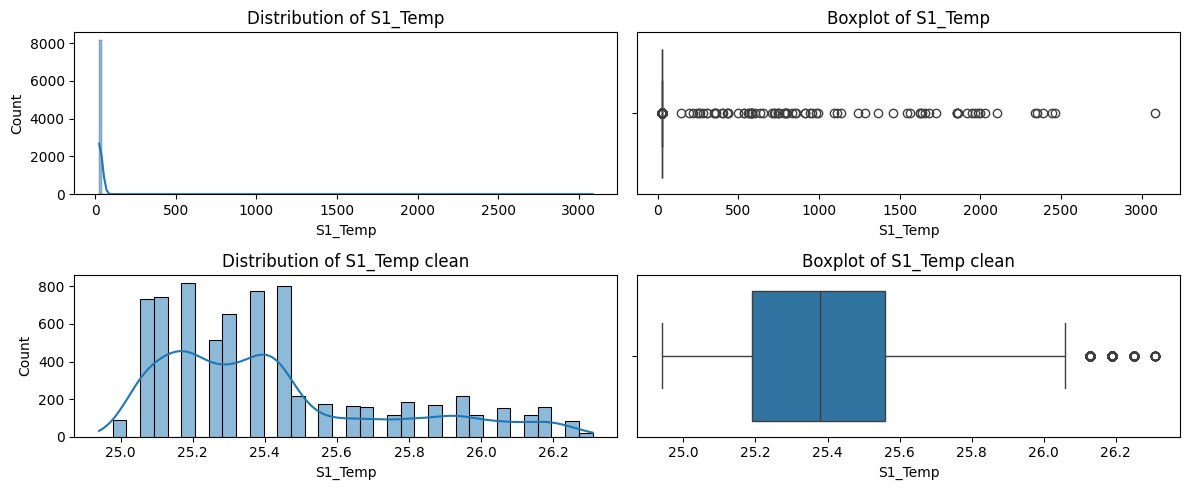

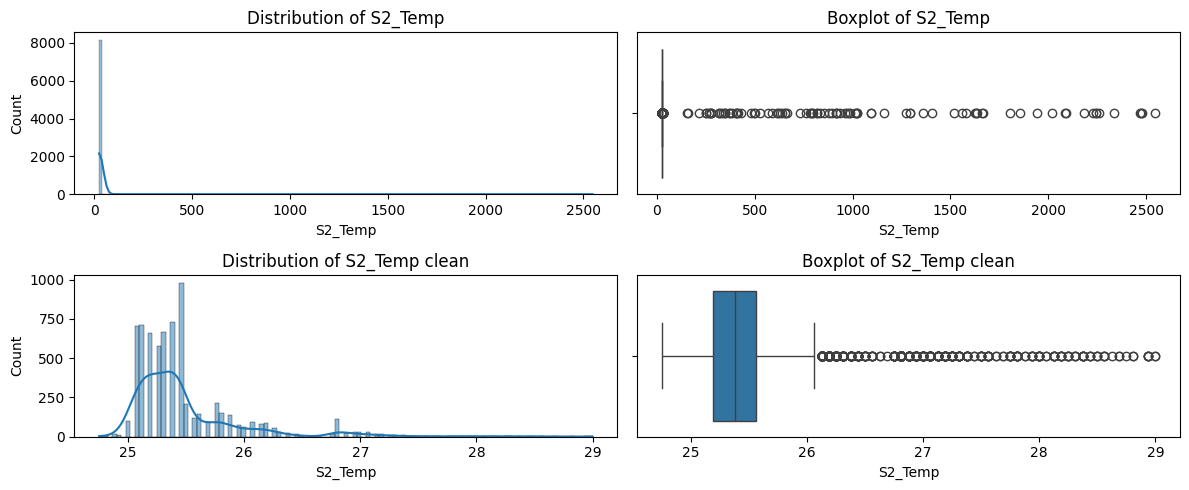

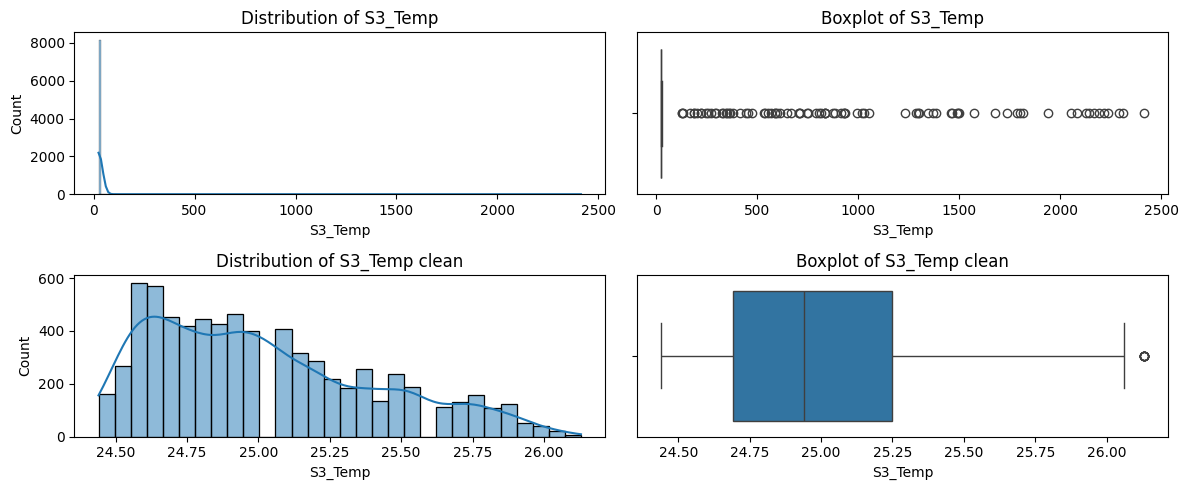

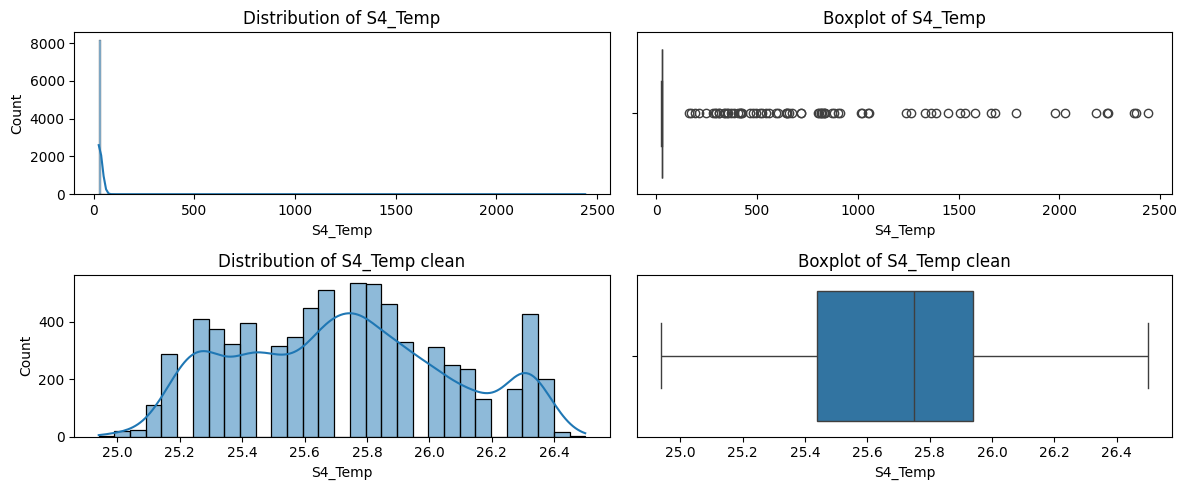

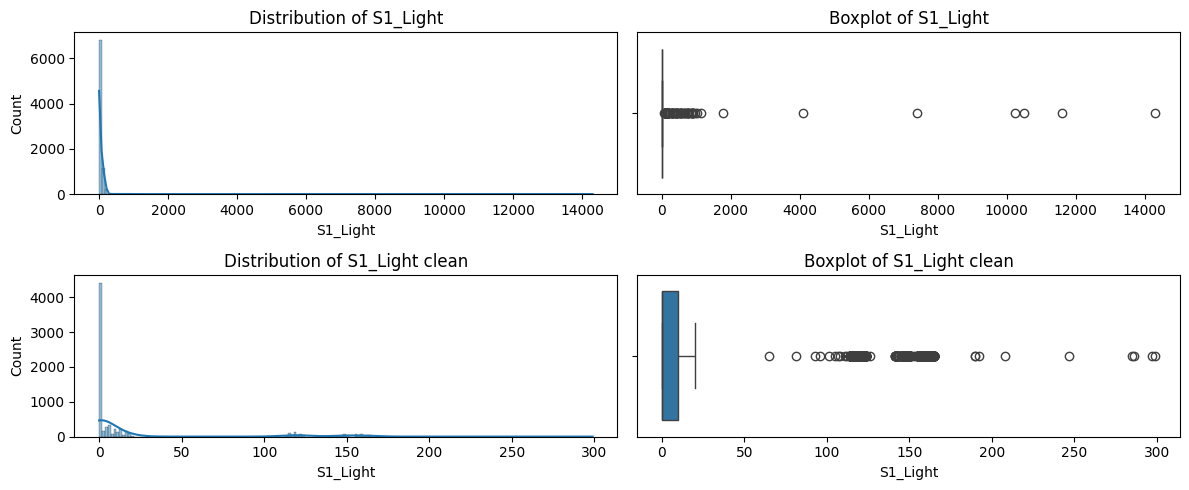

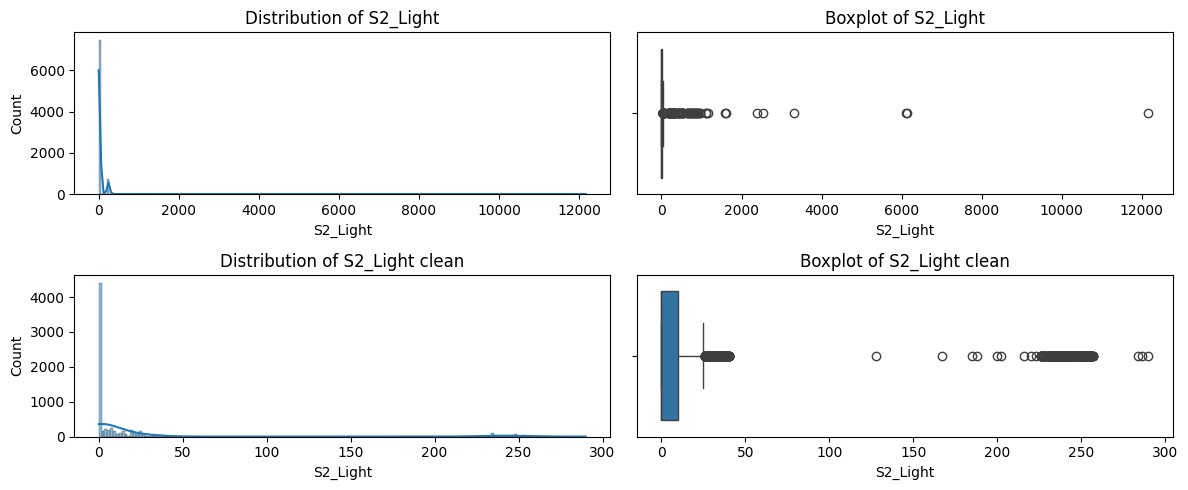

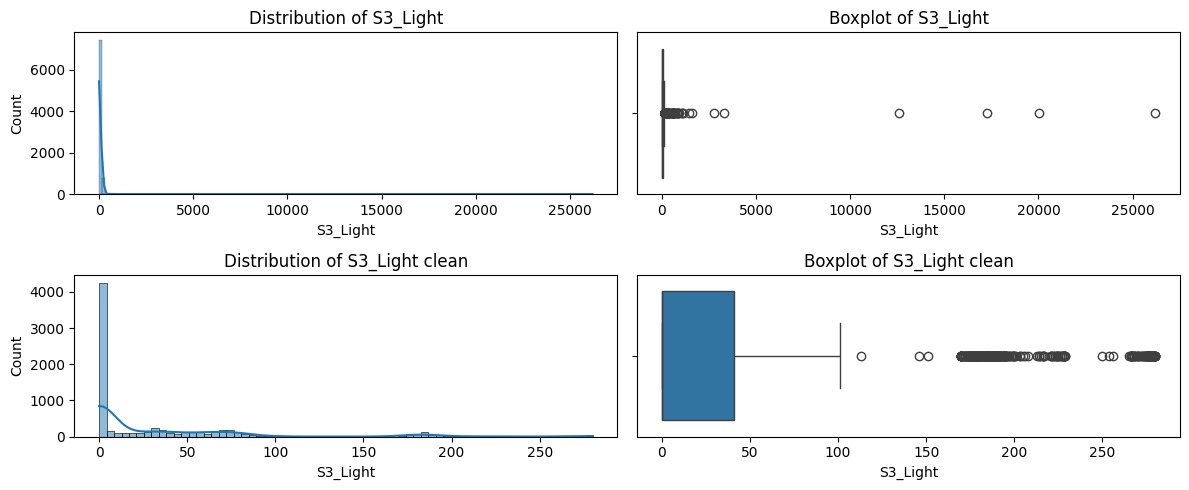

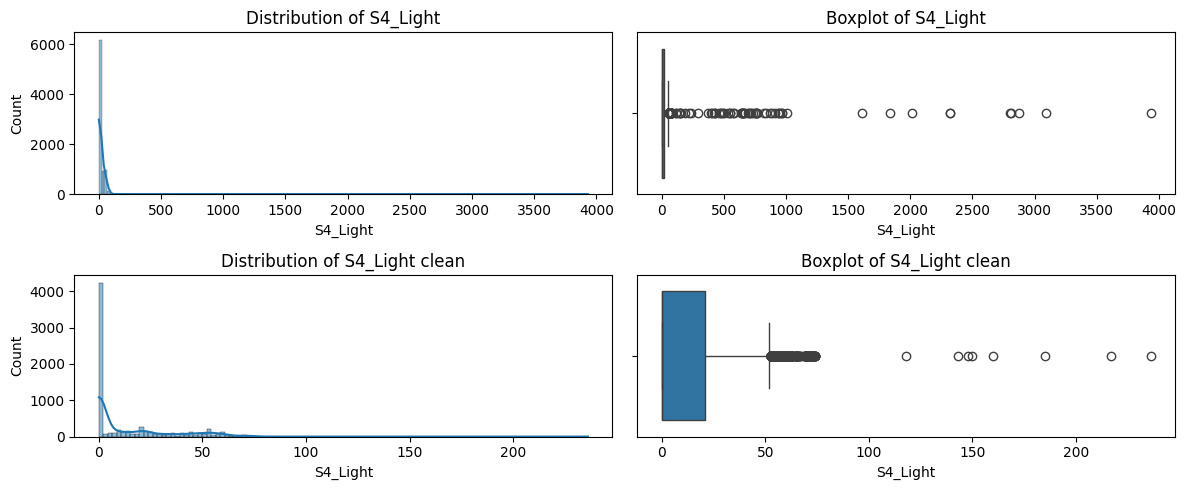

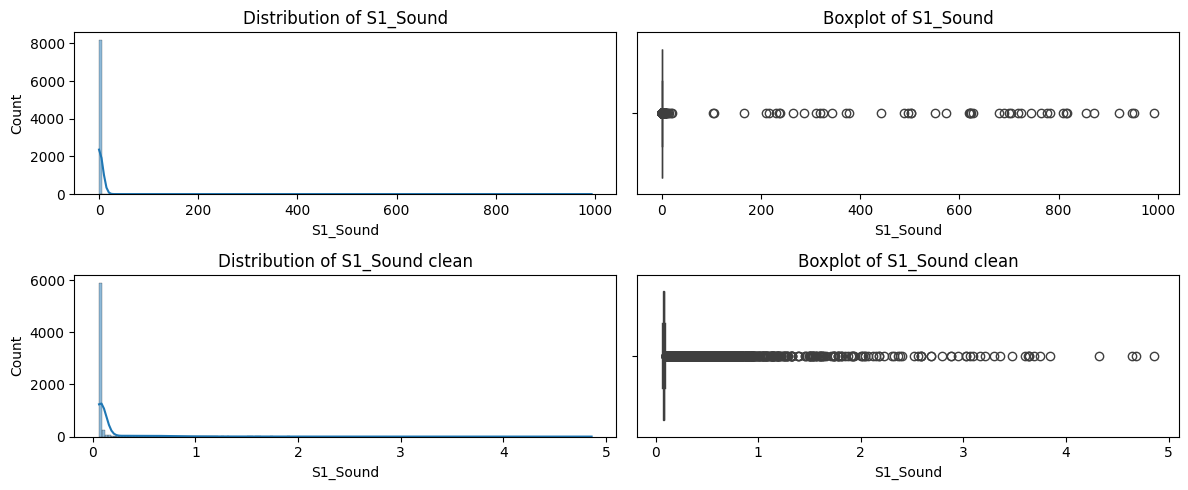

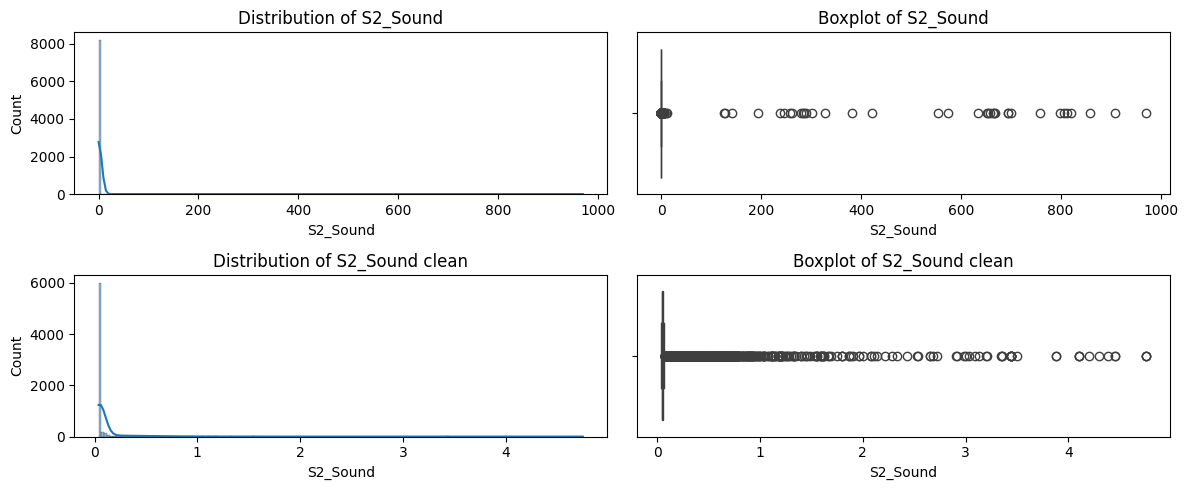

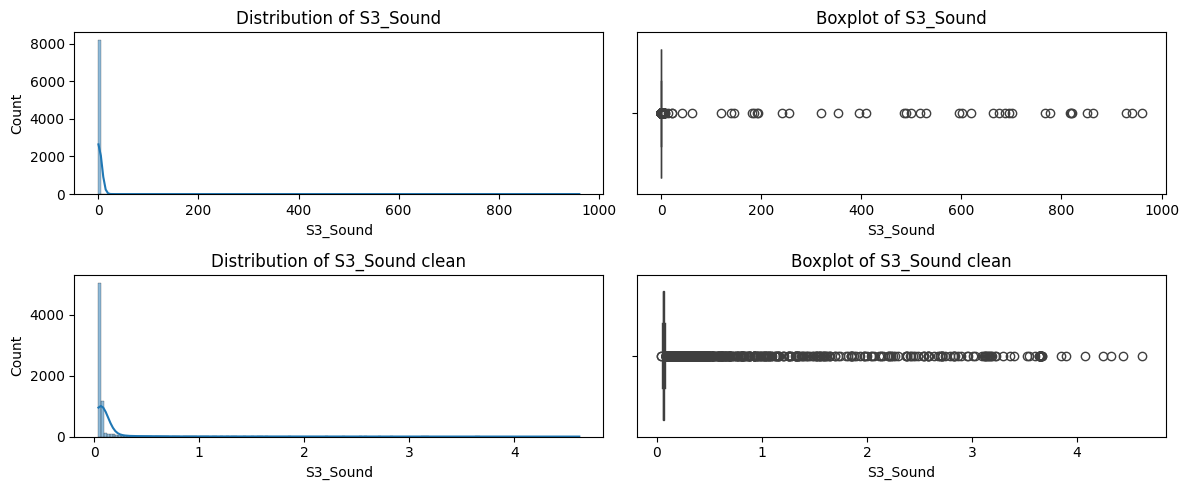

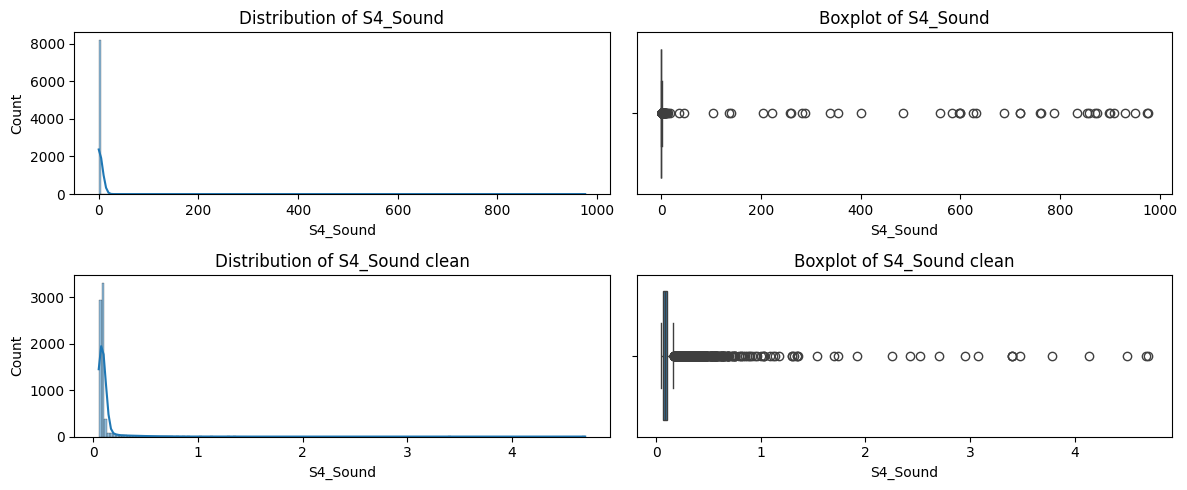

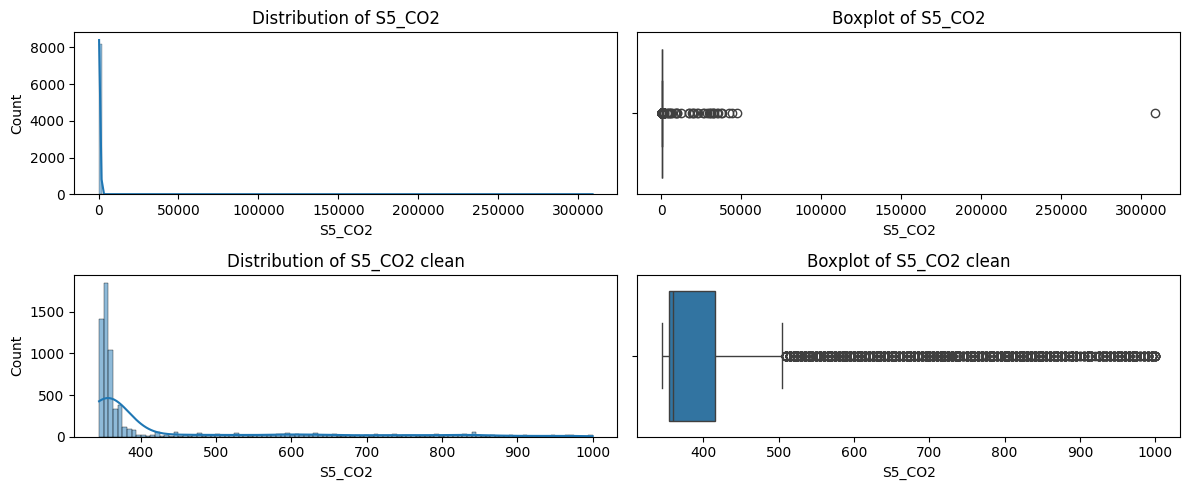

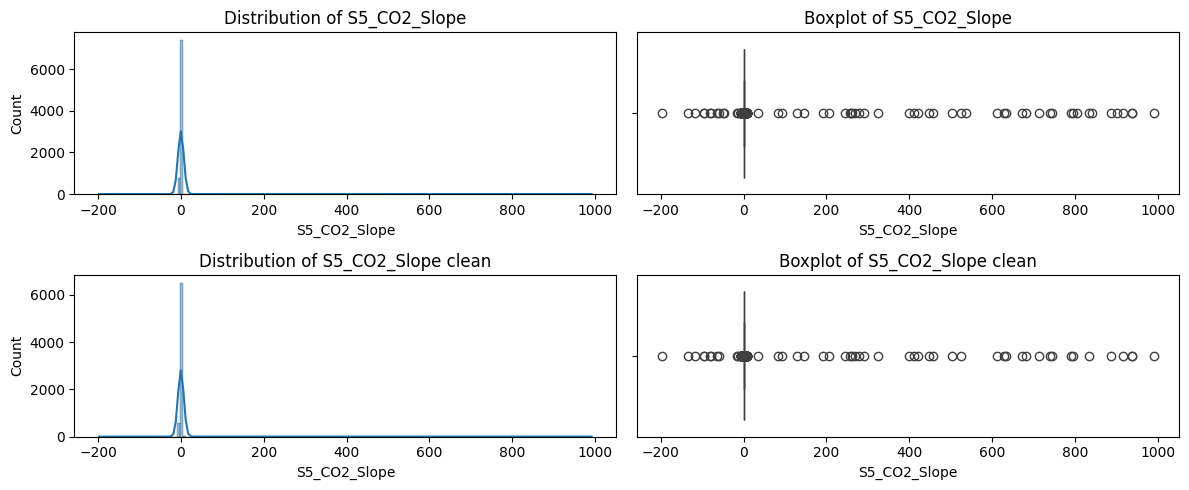

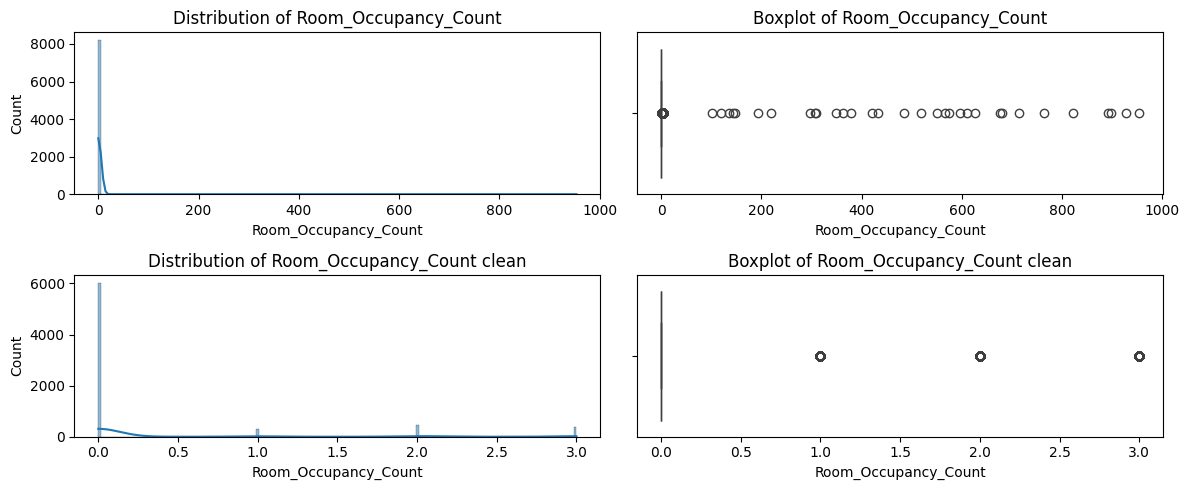

In [24]:
for column in numeric_cols:
    fig, axes = plt.subplots(2, 2, figsize=(12, 5))

    sns.histplot(
        data=modDF_delR,
        x=column,
        kde=True,
        ax=axes[0,0]
    )
    axes[0,0].set_title(f"Distribution of {column}")

    sns.boxplot(
        data=modDF_delR,
        x=column,
        ax=axes[0,1]
    )
    axes[0,1].set_title(f"Boxplot of {column}")

    sns.histplot(
            data=modDf_NumC,
            x=column,
            kde=True,
            ax=axes[1,0]
        )
    axes[1,0].set_title(f"Distribution of {column} clean")

    sns.boxplot(
        data=modDf_NumC,
        x=column,
        ax=axes[1,1]
    )
    axes[1,1].set_title(f"Boxplot of {column} clean")

    plt.tight_layout()
    plt.show()

### Variables binarias

In [30]:
boolean_cols = [
    "S6_PIR",
    "S7_PIR"
]

def booleanErrors(df: pd.DataFrame, colList: list):

    errors = []

    for col in colList:
        converted = pd.to_numeric(df[col], errors="coerce")

        # Invalid if:
        # 1. Value exists but can't be converted to numeric
        # 2. Converted value is something other than 0 or 1
        invalid = (
            df[col].notna() &
            (converted.isna() |
            ~converted.isin([0, 1])))

        for idx in df.index[invalid]:
            errors.append({
                "row": idx,
                "column": col,
                "value": df.loc[idx, col]
            })

    e_df = pd.DataFrame(errors)

    if e_df.empty:
        return [e_df, []]

    same_id_rows = e_df[e_df.duplicated(subset=["row"], keep=False)]

    return [e_df, list(set(same_id_rows["row"].to_list()))]

boolErrorDF, boolSameRows = booleanErrors(modDf_c,boolean_cols)

print(f'Columnas analizadas: {len(boolean_cols)}')
print(f'Filas con valores erroneos: {boolErrorDF.shape[0]}')
print(f'Filas con mas de un valor erroneo: {len(boolSameRows)}')
boolErrorDF.nunique()

Columnas analizadas: 2
Filas con valores erroneos: 175
Filas con mas de un valor erroneo: 1


row       174
column      2
value     101
dtype: int64

In [33]:
boolErrorDF

,row,column,value
0,50,S6_PIR,915.0
1,99,S6_PIR,643.0
2,125,S6_PIR,71.0
3,173,S6_PIR,195.0
4,216,S6_PIR,386.0
...,...,...,...
170,9674,S7_PIR,?
171,9683,S7_PIR,invalid
172,9848,S7_PIR,894.0
173,10070,S7_PIR,invalid


# ---------------------------------------------------------------------------------------------------------------------------------------------------------------

In [27]:
print(f"Rows: {modDf.shape[0]:,}")
print(f"Columns: {modDf.shape[1]}")

# Compact data-quality summary
data_quality = pd.DataFrame({
    "dtype": modDf.dtypes,
    "missing": modDf.isna().sum(),
    "missing_pct": modDf.isna().mean() * 100,
    "n_unique": modDf.nunique()
})

data_quality.sort_values("missing_pct", ascending=False)

Rows: 10,323
Columns: 19


,dtype,missing,missing_pct,n_unique
Room_Occupancy_Count,object,132,1.278698,56
S3_Light,object,131,1.269011,338
S2_Temp,object,128,1.239950,228
S3_Temp,object,124,1.201201,169
S2_Light,object,122,1.181827,218
S5_CO2,object,121,1.172140,381
S4_Light,object,118,1.143079,227
S7_PIR,object,116,1.123704,54
S2_Sound,object,115,1.114017,322
S1_Temp,object,115,1.114017,160


Para comenzar el análisis se le asignará un tipo de dato adecuado, para ello se verificará el tipo de error que volvio los campos a tipo objeto.

In [28]:
numType = [np.number for i in range(14)] # Desde S1_Temp hasta S5_CO2_Slope pueden ser considerados numeros aun no se identifica si son tipo float o int
dtL = [np.datetime64,np.timedelta64, *numType, bool, bool, object] # Los sensores PIR son detection de persona(s) por lo que es del tipo binario 

numeric_cols = [
    "S1_Temp", "S2_Temp", "S3_Temp", "S4_Temp",
    "S1_Light", "S2_Light", "S3_Light", "S4_Light",
    "S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound",
    "S5_CO2", "S5_CO2_Slope",
    "Room_Occupancy_Count"
]

boolean_cols = [
    "S6_PIR",
    "S7_PIR"
]

def is_numeric(value):
    if pd.isna(value):
        return False
    
    try:
        float(value)
        return True
    except (ValueError, TypeError):
        return False


def is_boolean(value):
    if pd.isna(value):
        return False
    
    return str(value).strip().lower() in [
        "0", "1",
        "true", "false"
    ]


def is_date(value):
    if pd.isna(value):
        return False
    
    try:
        pd.to_datetime(value, format="%Y/%m/%d")
        return True
    except (ValueError, TypeError):
        return False


def is_time(value):
    if pd.isna(value):
        return False
    
    try:
        pd.to_timedelta(str(value))
        return True
    except (ValueError, TypeError):
        return False

invalid = pd.DataFrame(
    False,
    index=modDf.index,
    columns=modDf.columns
)

invalid["Date"] = ~modDf["Date"].apply(is_date)
# invalid["Time"] = modDf["Time"].apply(is_time)

# for col in numeric_cols:
#     invalid[col] = modDf[col].apply(is_numeric)

# for col in boolean_cols:
#     invalid[col] = modDf[col].apply(is_boolean)

bad_rows = modDf[invalid.any(axis=1)]
good_rows = modDf[~invalid.any(axis=1)]

print("Valid rows:", len(good_rows))
print("Invalid rows:", len(bad_rows))

Valid rows: 10233
Invalid rows: 90


In [29]:
bad_rows

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
105,NaT,0 days 11:45:51,25.5,25.63,24.94,25.81,155.0,235.0,71.0,55.0,2.01,0.32,0.11,0.09,515.0,3.33846153846,0.0,0.0,2.0
377,NaT,0 days 14:31:47,26.06,26.38,25.94,26.31,18.0,22.0,96.0,60.0,0.07,0.05,0.06,0.06,910.0,-1.86538461538,0.0,0.0,0.0
719,NaT,0 days 17:29:28,26.25,25.75,25.75,26.31,114.0,24.0,176.0,10.0,1.5,0.37,0.79,0.56,800.0,2.15,1.0,1.0,2.0
835,NaT,0 days 18:30:14,26.25,26.63,25.94,26.44,150.0,236.0,180.0,11.0,0.4,1.49,0.99,0.29,1090.0,2.14615384615,0.0,1.0,3.0
918,NaT,0 days 19:13:07,26.38,27.88,26.06,26.44,150.0,239.0,181.0,11.0,0.14,0.14,0.06,930.07,1200.0,-0.265384615385,0.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9872,NaT,0 days 06:47:55,25.13,25.06,24.5,25.19,0.0,0.0,0.0,0.0,0.08,0.04,0.06,0.08,345.0,0.0,0.0,0.0,0.0
9906,NaT,0 days 07:05:16,25.06,25.06,24.56,25.19,0.0,0.0,3.0,2.0,0.08,0.05,0.06,0.09,345.0,0.0,0.0,0.0,0.0
9909,NaT,0 days 07:06:48,25.06,25.06,24.56,25.19,0.0,0.0,3.0,2.0,0.08,0.05,0.06,0.08,345.0,0.0,0.0,0.0,0.0
10188,NaT,0 days 18:09:48,26.25,26.38,26.06,26.38,148.0,234.0,177.0,10.0,0.66,0.33,1.26,0.37,995.0,4.15,0.0,1.0,3.0
